<a href="https://colab.research.google.com/github/younus1082/Neural-Networks-Lab/blob/main/Lab%20Assignment%204/Assignment_4_1082_A2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1. Library Imports and Device Configuration
This section prepares the environment. We use GPU if available to speed up the process.

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Set device (GPU if available)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


# 2. Data Preprocessing (Requirement 1)
We are using CIFAR-10. We normalize the pixel values to a mean and standard deviation of 0.5 (scaling them to approximately $[-1, 1]$) and split them into Training and Testing sets.

In [5]:
# Transformation: Convert to tensor and normalize
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Load datasets
train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# Data Loaders (Requirement: Split into training and testing)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
print("Data preprocessing complete.")

Data preprocessing complete.


# 3. CNN Model Implementation (Requirement 2 + Bonus)
This model implements two convolutional layers, ReLU activation, Max Pooling, and a Flatten layer.
Bonus Features included: Batch Normalization (to stabilize learning) and Dropout (to prevent overfitting).

In [6]:
class MyCNN(nn.Module):
    def __init__(self):
        super(MyCNN, self).__init__()

        # Conv Layer 1: Input (3, 32, 32) -> Output (32, 32, 32)
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32) # BONUS: Batch Normalization

        # Conv Layer 2: Input (32, 16, 16) -> Output (64, 16, 16)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64) # BONUS: Batch Normalization

        # Requirement: Pooling layer
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # BONUS: Dropout layer to prevent overfitting
        self.dropout = nn.Dropout(0.25)

        # Requirement: Flatten and Fully Connected Layers
        # After two pools (32->16->8), the image size is 8x8. 64 filters * 8 * 8 = 4096
        self.fc1 = nn.Linear(64 * 8 * 8, 512)
        self.fc2 = nn.Linear(512, 10) # Output layer (10 classes)

    def forward(self, x):
        # Layer 1: Conv -> BN -> ReLU -> Pool
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        # Layer 2: Conv -> BN -> ReLU -> Pool
        x = self.pool(F.relu(self.bn2(self.conv2(x))))

        # Requirement: Flatten
        x = x.view(-1, 64 * 8 * 8)

        x = F.relu(self.fc1(x))
        x = self.dropout(x) # Applying Dropout
        x = self.fc2(x) # Softmax is applied internally by CrossEntropyLoss
        return x

model = MyCNN().to(device)
print(model)

MyCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=4096, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=10, bias=True)
)


# 4. Model Training (Requirement 3)
We use Categorical Crossentropy (via nn.CrossEntropyLoss) and the Adam optimizer. We will train for exactly 10 epochs.

In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# To store progress for visualization
history = {'train_loss': [], 'test_acc': [], 'test_loss': []}

print("Starting training...")
for epoch in range(10):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    # Evaluation for validation metrics
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    history['train_loss'].append(running_loss/len(train_loader))
    history['test_loss'].append(val_loss/len(test_loader))
    history['test_acc'].append(100 * correct / total)

    print(f"Epoch [{epoch+1}/10], Train Loss: {history['train_loss'][-1]:.4f}, Test Acc: {history['test_acc'][-1]:.2f}%")

Starting training...
Epoch [1/10], Train Loss: 1.3735, Test Acc: 62.75%
Epoch [2/10], Train Loss: 1.0333, Test Acc: 67.27%
Epoch [3/10], Train Loss: 0.9031, Test Acc: 69.83%
Epoch [4/10], Train Loss: 0.8124, Test Acc: 71.73%
Epoch [5/10], Train Loss: 0.7397, Test Acc: 72.46%
Epoch [6/10], Train Loss: 0.6764, Test Acc: 74.50%
Epoch [7/10], Train Loss: 0.6239, Test Acc: 74.65%
Epoch [8/10], Train Loss: 0.5680, Test Acc: 74.17%
Epoch [9/10], Train Loss: 0.5248, Test Acc: 74.91%
Epoch [10/10], Train Loss: 0.4790, Test Acc: 75.53%


# 5. Evaluation and Visualization (Requirement 4 & 5)
This generates the accuracy report, confusion matrix, and plots.

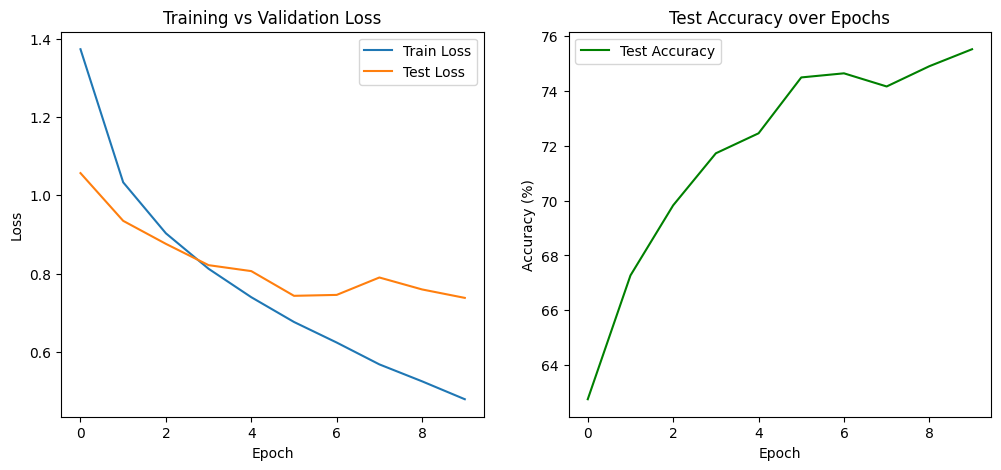

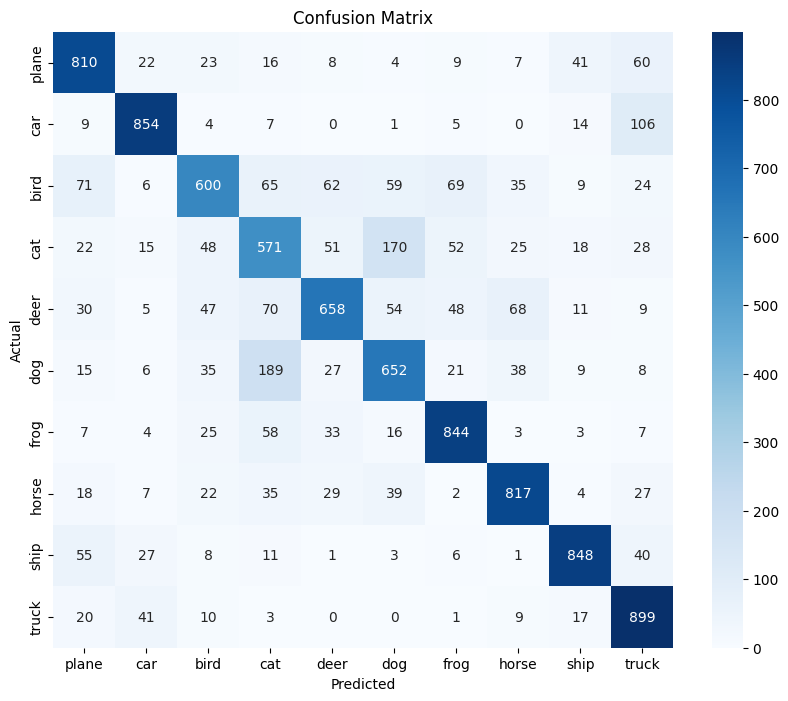

In [8]:
# Plot Training vs Validation Loss and Accuracy
plt.figure(figsize=(12, 5))

# Loss Plot
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['test_loss'], label='Test Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy Plot
plt.subplot(1, 2, 2)
plt.plot(history['test_acc'], label='Test Accuracy', color='green')
plt.title('Test Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.show()

# Confusion Matrix
model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 6. Analysis

* **What is the role of convolution layers?**
In your model, the convolutional layers (`conv1` and `conv2`) acted as automated feature extractors. By sliding learnable filters over the CIFAR-10 images, they identified spatial patterns. The first layer likely captured low-level features like edges and colors, while the second layer combined those into more complex shapes. This allowed the network to "understand" the visual content of the images before classification.

* **Why is pooling used?**
Pooling (specifically `MaxPool2d` in your code) was used to reduce the spatial dimensions of the feature maps (downsampling from $32 \times 32$ to $16 \times 16$ and finally $8 \times 8$). This serves two purposes:

1. **Efficiency:** It significantly reduces the number of parameters and computational load for the following layers.

2. **Invariance:** It helps the model become more robust to small shifts or distortions in the position of objects within the image.


* **What happens if we increase the number of filters?**
Increasing the number of filters (e.g., changing 32 and 64 to higher numbers) would allow the network to learn a wider variety of features and potentially improve accuracy on complex datasets. However, it would also increase the memory footprint and training time. If the number is too high relative to the amount of data, it could lead to overfitting.

* **What is overfitting in CNN? Did it occur in your model?**
Overfitting occurs when a model learns the specific noise and details of the training data so well that it fails to generalize to new, unseen images (the test set).

**Observation from your output:**
Looking at your epoch logs:
* **Train Loss** decreased steadily from **1.3735** to **0.4790**.
* **Test Accuracy** increased significantly at first but began to plateau around **75.53%** in the final epochs.

* **Analysis:** There is a slight hint of overfitting beginning to occur. While the training loss continues to drop sharply, the test accuracy is slowing down. However, because you used **Dropout** (self.dropout = nn.Dropout(0.25)) and **Batch Normalization**, the overfitting was largely kept under control, allowing the model to maintain a respectable 75% accuracy on the test set.